In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [6]:
df=pd.read_excel("data/WQD.xlsx")

In [7]:
df.head()

,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
0,67.448725,10.127148,0.208153,7.473607,10.181084,4.751657,218.364855,300.125080,337.178226,0.286054,4.355310,0.005984,0.066793,6069.624017,2
1,64.626666,94.015595,11.434463,10.859998,14.860521,3.085154,273.939692,8.426776,363.660740,0.096040,2.182753,0.004906,0.023428,250.995959,2
2,65.121842,90.653462,12.430865,12.809970,12.319980,9.648515,220.812730,11.726274,309.370934,0.974501,4.901760,0.006979,0.065041,7218.927473,2
3,1.640334,0.066344,10.963529,8.508023,12.955209,4.819988,266.571628,6.627655,8.180468,0.884865,3.571842,3.174473,0.026018,1230.062252,2
4,64.863434,2.119173,1.361736,13.335372,13.603197,10.244034,252.108000,339.891514,253.996871,0.801695,4.655898,3.854701,0.060995,1035.054820,2


In [8]:
sensor_cost = {
    'Temp': 1,
    'Turbidity (cm)': 2,
    'DO(mg/L)': 4,
    'BOD (mg/L)': 5,
    'CO2': 4,
    'pH`': 2,               # note the backtick in column name
    'Alkalinity (mg L-1 )': 4,
    'Hardness (mg L-1 )': 4,
    'Calcium (mg L-1 )': 5,
    'Ammonia (mg L-1 )': 4,
    'Nitrite (mg L-1 )': 4,
    'Phosphorus (mg L-1 )': 4,
    'H2S (mg L-1 )': 4,
    'Plankton (No. L-1)': 6
}

# Create a DataFrame for reference
cost_df = pd.DataFrame(list(sensor_cost.items()), columns=['Feature', 'Cost'])
cost_df = cost_df.sort_values('Cost')
print(cost_df)

                 Feature  Cost
0                   Temp     1
1         Turbidity (cm)     2
5                    pH`     2
2               DO(mg/L)     4
4                    CO2     4
6   Alkalinity (mg L-1 )     4
7     Hardness (mg L-1 )     4
9      Ammonia (mg L-1 )     4
10     Nitrite (mg L-1 )     4
11  Phosphorus (mg L-1 )     4
12         H2S (mg L-1 )     4
3             BOD (mg/L)     5
8      Calcium (mg L-1 )     5
13    Plankton (No. L-1)     6


In [9]:
cost_df

,Feature,Cost
0,Temp,1
1,Turbidity (cm),2
5,pH`,2
2,DO(mg/L),4
4,CO2,4
6,Alkalinity (mg L-1 ),4
7,Hardness (mg L-1 ),4
9,Ammonia (mg L-1 ),4
10,Nitrite (mg L-1 ),4
11,Phosphorus (mg L-1 ),4


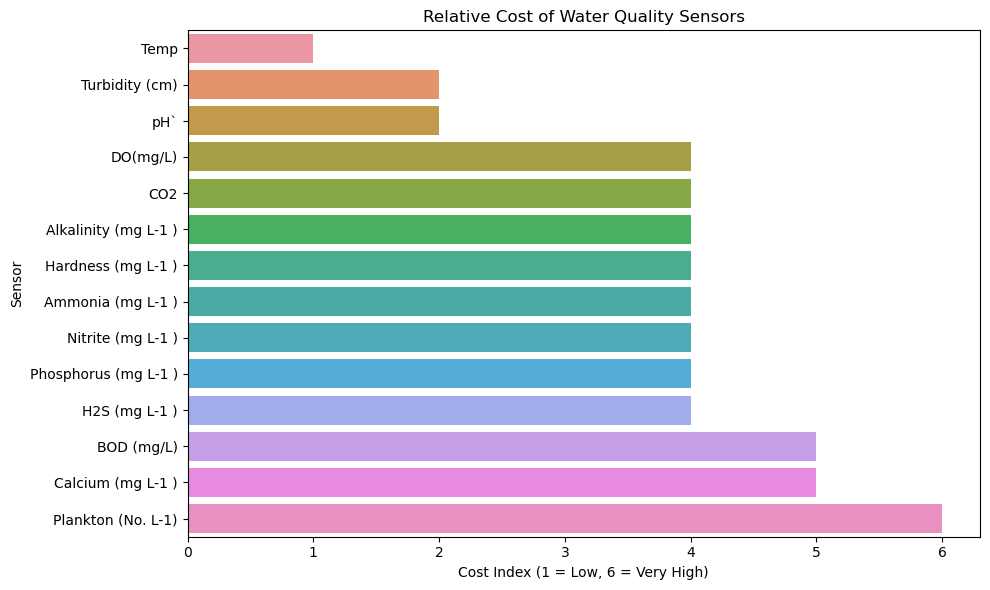

In [10]:
plt.figure(figsize=(10,6))
sns.barplot(data=cost_df, x="Cost", y="Feature")
plt.title("Relative Cost of Water Quality Sensors")
plt.xlabel("Cost Index (1 = Low, 6 = Very High)")
plt.ylabel("Sensor")
plt.tight_layout()
plt.show()


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

X = df.drop("Water Quality", axis=1)
y = df["Water Quality"]


In [12]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [13]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
from sklearn.metrics import accuracy_score


train_pred = rf.predict(X_train)
print("Training Accuracy:", accuracy_score(y_train, train_pred))

Training Accuracy: 1.0


In [15]:
test_pred = rf.predict(X_test)
print("Testing Accuracy:", accuracy_score(y_test, test_pred))


Testing Accuracy: 0.9930232558139535


In [16]:
acc_all = accuracy_score(y_test, test_pred)

In [17]:
from sklearn.model_selection import StratifiedKFold


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf, X, y, cv=skf, scoring='accuracy')

print("Cross Validation Accuracy:", cv_scores.mean())
print("Std Deviation:", cv_scores.std())

Cross Validation Accuracy: 0.9955813953488372
Std Deviation: 0.0031545720851745224


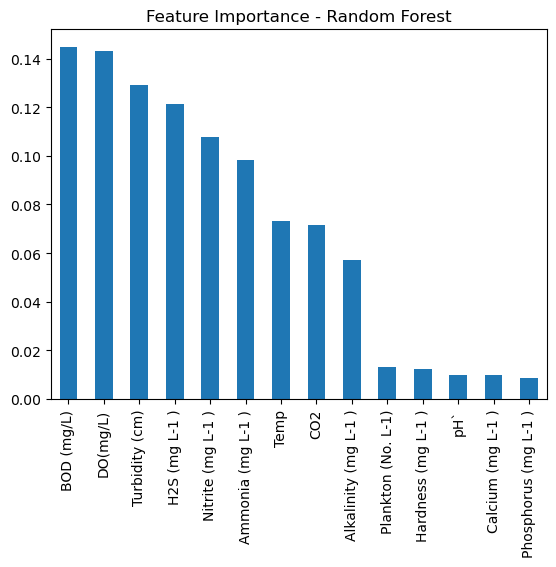

In [18]:
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.plot(kind='bar')
plt.title("Feature Importance - Random Forest")
plt.show()

In [19]:
importances = rf.feature_importances_
feature_names = X.columns
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False)
print("\nFeature importances:\n", imp_df)


Feature importances:
                  Feature  Importance
3             BOD (mg/L)    0.144742
2               DO(mg/L)    0.142927
1         Turbidity (cm)    0.129231
12         H2S (mg L-1 )    0.121484
10     Nitrite (mg L-1 )    0.107773
9      Ammonia (mg L-1 )    0.098386
0                   Temp    0.073307
4                    CO2    0.071372
6   Alkalinity (mg L-1 )    0.057010
13    Plankton (No. L-1)    0.013087
7     Hardness (mg L-1 )    0.012274
5                    pH`    0.009849
8      Calcium (mg L-1 )    0.009768
11  Phosphorus (mg L-1 )    0.008788


In [20]:
imp_cost_df = imp_df.merge(cost_df, on='Feature', how='left')
imp_cost_df['Imp/Cost'] = imp_cost_df['Importance'] / imp_cost_df['Cost']
imp_cost_df = imp_cost_df.sort_values('Imp/Cost', ascending=False)
print(imp_cost_df)

                 Feature  Importance  Cost  Imp/Cost
6                   Temp    0.073307     1  0.073307
2         Turbidity (cm)    0.129231     2  0.064616
1               DO(mg/L)    0.142927     4  0.035732
3          H2S (mg L-1 )    0.121484     4  0.030371
0             BOD (mg/L)    0.144742     5  0.028948
4      Nitrite (mg L-1 )    0.107773     4  0.026943
5      Ammonia (mg L-1 )    0.098386     4  0.024597
7                    CO2    0.071372     4  0.017843
8   Alkalinity (mg L-1 )    0.057010     4  0.014252
11                   pH`    0.009849     2  0.004925
10    Hardness (mg L-1 )    0.012274     4  0.003069
13  Phosphorus (mg L-1 )    0.008788     4  0.002197
9     Plankton (No. L-1)    0.013087     6  0.002181
12     Calcium (mg L-1 )    0.009768     5  0.001954


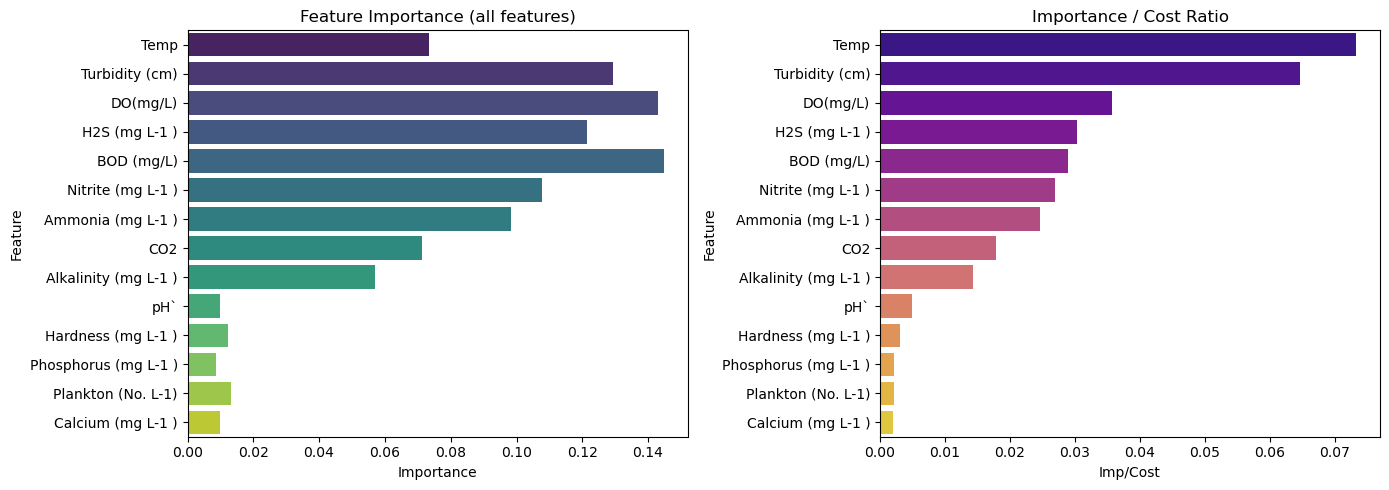

In [21]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=imp_cost_df, x='Importance', y='Feature', ax=axes[0], palette='viridis')
axes[0].set_title('Feature Importance (all features)')
sns.barplot(data=imp_cost_df, x='Imp/Cost', y='Feature', ax=axes[1], palette='plasma')
axes[1].set_title('Importance / Cost Ratio')
plt.tight_layout()
plt.show()

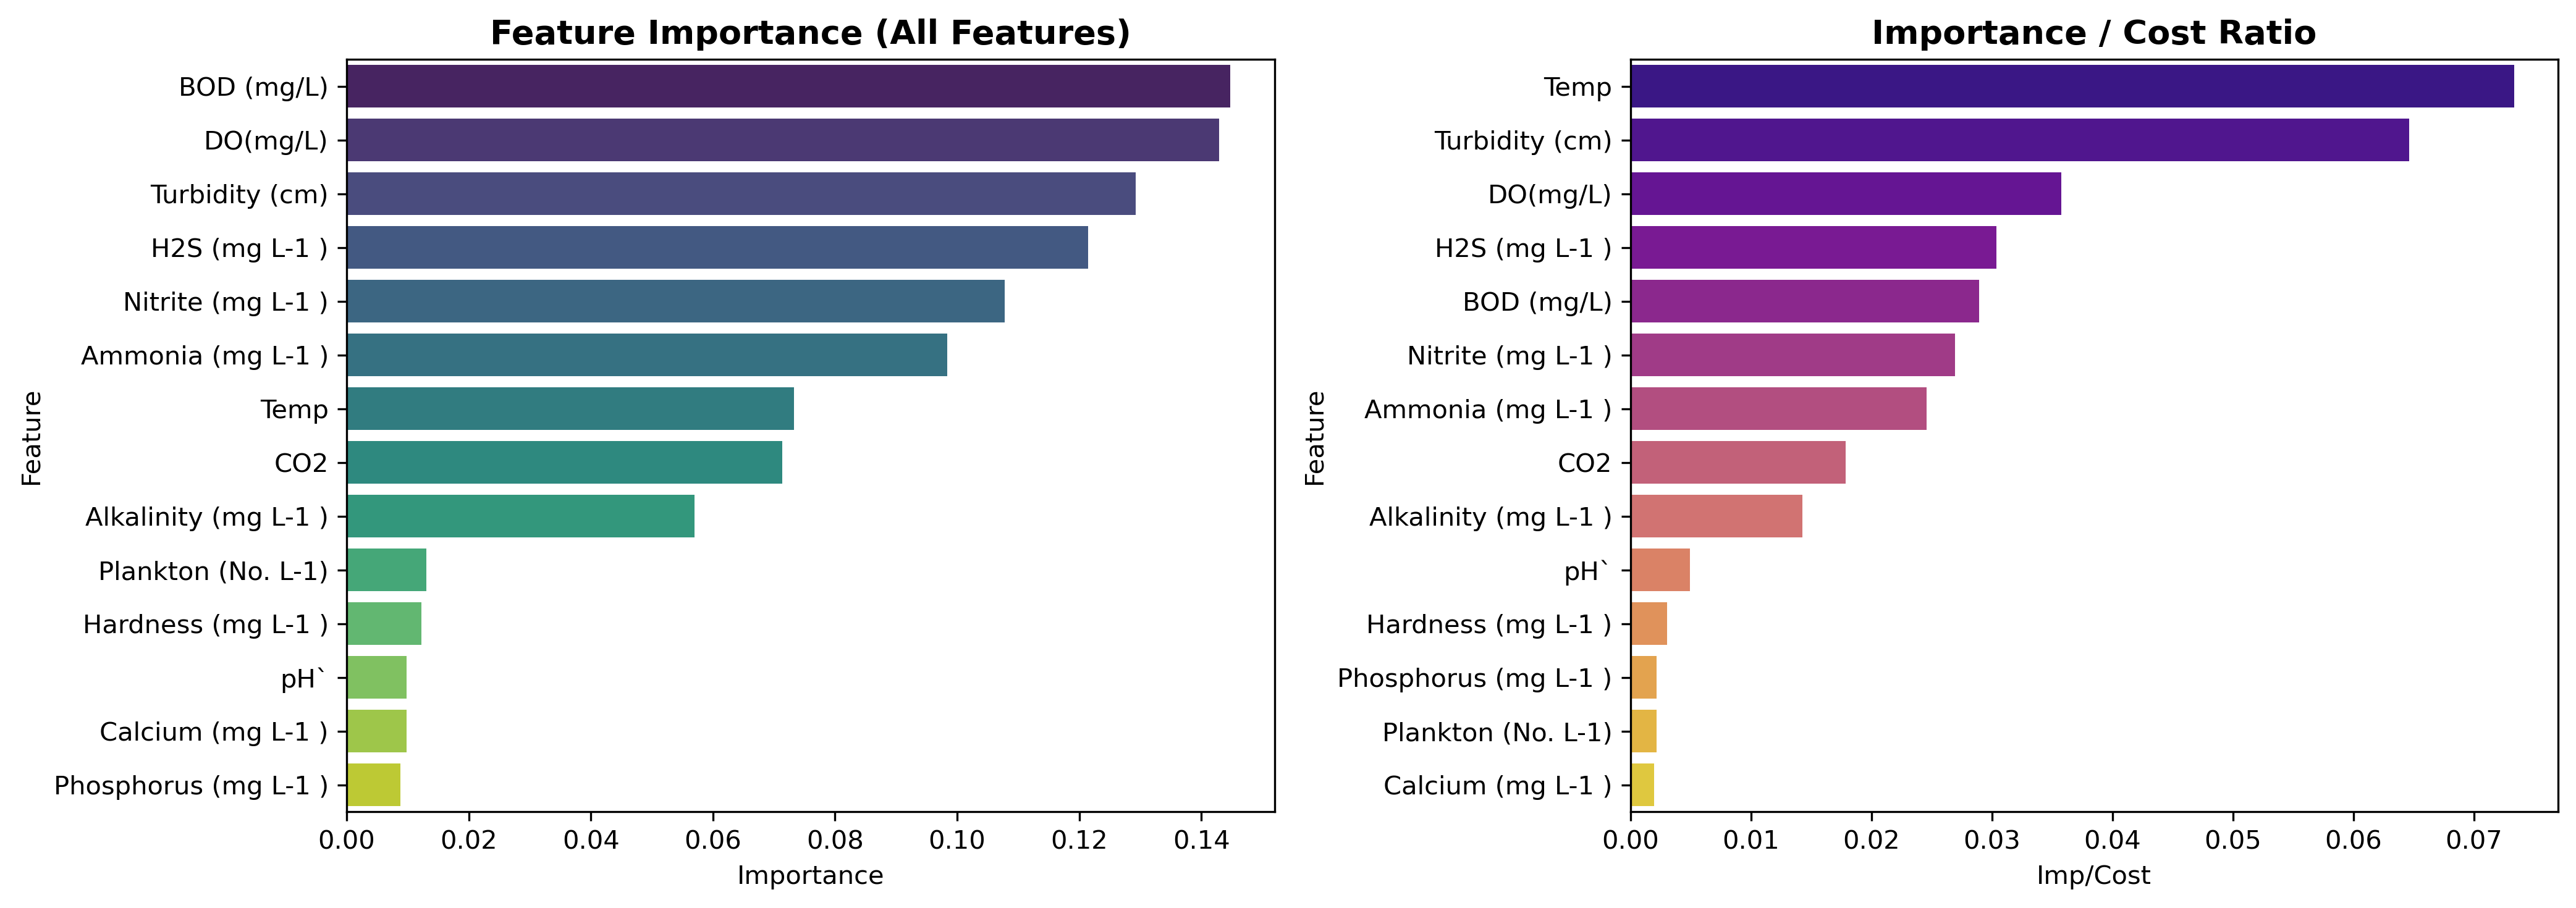

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort separately
imp_sorted = imp_cost_df.sort_values(
    by='Importance',
    ascending=False
)

ratio_sorted = imp_cost_df.sort_values(
    by='Imp/Cost',
    ascending=False
)

# High-quality figure settings
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

# Feature Importance Plot
sns.barplot(
    data=imp_sorted,
    x='Importance',
    y='Feature',
    ax=axes[0],
    palette='viridis'
)
axes[0].set_title(
    'Feature Importance (All Features)',
    fontsize=13,
    fontweight='bold'
)

# Importance / Cost Ratio Plot
sns.barplot(
    data=ratio_sorted,
    x='Imp/Cost',
    y='Feature',
    ax=axes[1],
    palette='plasma'
)
axes[1].set_title(
    'Importance / Cost Ratio',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

# Save as high-quality PNG
plt.savefig(
    "feature_importance_and_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

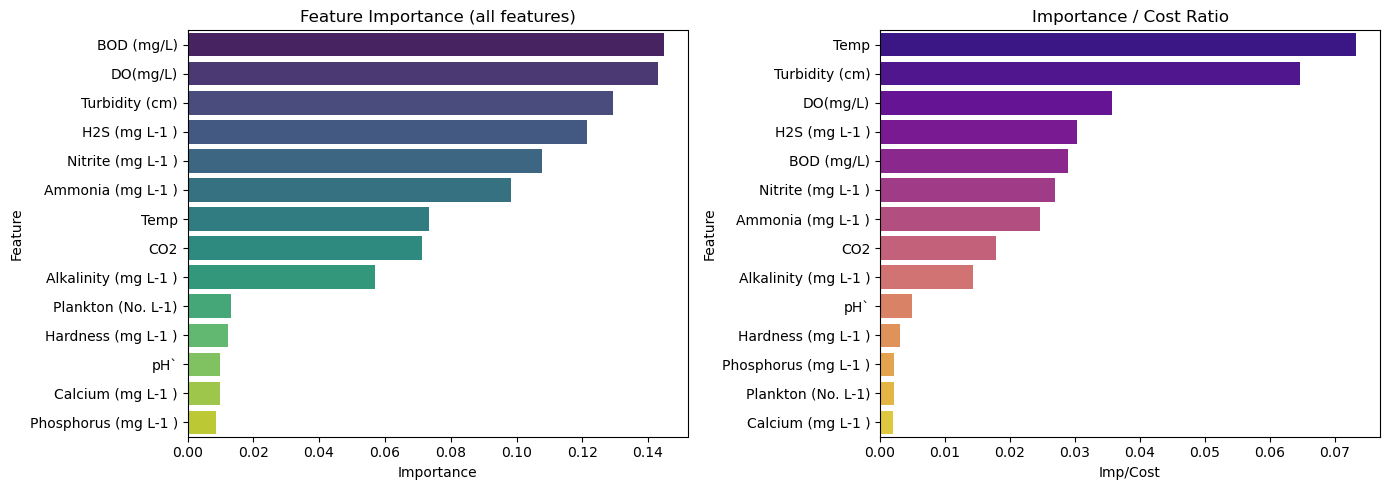

In [ ]:
# # Sort separately
# imp_sorted = imp_cost_df.sort_values(by='Importance', ascending=False)
# ratio_sorted = imp_cost_df.sort_values(by='Imp/Cost', ascending=False)

# # Visualize
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# sns.barplot(
#     data=imp_sorted,
#     x='Importance',
#     y='Feature',
#     ax=axes[0],
#     palette='viridis'
# )
# axes[0].set_title('Feature Importance (all features)')

# sns.barplot(
#     data=ratio_sorted,
#     x='Imp/Cost',
#     y='Feature',
#     ax=axes[1],
#     palette='plasma'
# )
# axes[1].set_title('Importance / Cost Ratio')

# plt.tight_layout()
# plt.show()

In [25]:
# Sort features by Imp/Cost (descending)
selected_features = imp_cost_df['Feature'].tolist()  # order by Imp/Cost
print("Feature addition order (by Imp/Cost):", selected_features)

Feature addition order (by Imp/Cost): ['Temp', 'Turbidity (cm)', 'DO(mg/L)', 'H2S (mg L-1 )', 'BOD (mg/L)', 'Nitrite (mg L-1 )', 'Ammonia (mg L-1 )', 'CO2', 'Alkalinity (mg L-1 )', 'pH`', 'Hardness (mg L-1 )', 'Phosphorus (mg L-1 )', 'Plankton (No. L-1)', 'Calcium (mg L-1 )']


In [26]:
# Lists to store results
n_features_list = []
cost_list = []
accuracy_list = []
feature_subsets = []

# Start with empty set, add features sequentially
for i in range(1, len(selected_features) + 1):
    subset = selected_features[:i]
    feature_subsets.append(subset)
    
    # Select subset from train/test
    X_train_sub = X_train[subset]
    X_test_sub = X_test[subset]
    
    # Train RF
    rf_sub = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_sub.fit(X_train_sub, y_train)
    
    # Predict and evaluate
    y_pred_sub = rf_sub.predict(X_test_sub)
    acc = accuracy_score(y_test, y_pred_sub)
    
    # Calculate cumulative cost
    cum_cost = sum([sensor_cost[feat] for feat in subset])
    
    n_features_list.append(i)
    cost_list.append(cum_cost)
    accuracy_list.append(acc)
    
    print(f"Features: {i}, Cumulative cost: {cum_cost}, Accuracy: {acc:.4f}")


Features: 1, Cumulative cost: 1, Accuracy: 0.5384
Features: 2, Cumulative cost: 3, Accuracy: 0.7453
Features: 3, Cumulative cost: 7, Accuracy: 0.8523
Features: 4, Cumulative cost: 11, Accuracy: 0.8919
Features: 5, Cumulative cost: 16, Accuracy: 0.9337
Features: 6, Cumulative cost: 20, Accuracy: 0.9430
Features: 7, Cumulative cost: 24, Accuracy: 0.9453
Features: 8, Cumulative cost: 28, Accuracy: 0.9919
Features: 9, Cumulative cost: 32, Accuracy: 0.9942
Features: 10, Cumulative cost: 34, Accuracy: 0.9942
Features: 11, Cumulative cost: 38, Accuracy: 0.9930
Features: 12, Cumulative cost: 42, Accuracy: 0.9930
Features: 13, Cumulative cost: 48, Accuracy: 0.9930
Features: 14, Cumulative cost: 53, Accuracy: 0.9930


In [27]:
results_df = pd.DataFrame({
    'Step': range(1, len(accuracy_list)+1),
    'Num_Features': n_features_list,
    'Cumulative_Cost': cost_list,
    'Accuracy': accuracy_list,
    'Features': [', '.join(subset) for subset in feature_subsets]
})

# Show the table (adjust display options if needed)
pd.set_option('display.max_colwidth', 50)  # to avoid wrapping long feature lists
print("\n=== Sequential Feature Addition Results ===\n")
print(results_df.to_string(index=False))


=== Sequential Feature Addition Results ===

 Step  Num_Features  Cumulative_Cost  Accuracy                                                                                                                                                                                                         Features
    1             1                1  0.538372                                                                                                                                                                                                             Temp
    2             2                3  0.745349                                                                                                                                                                                             Temp, Turbidity (cm)
    3             3                7  0.852326                                                                                                                                            

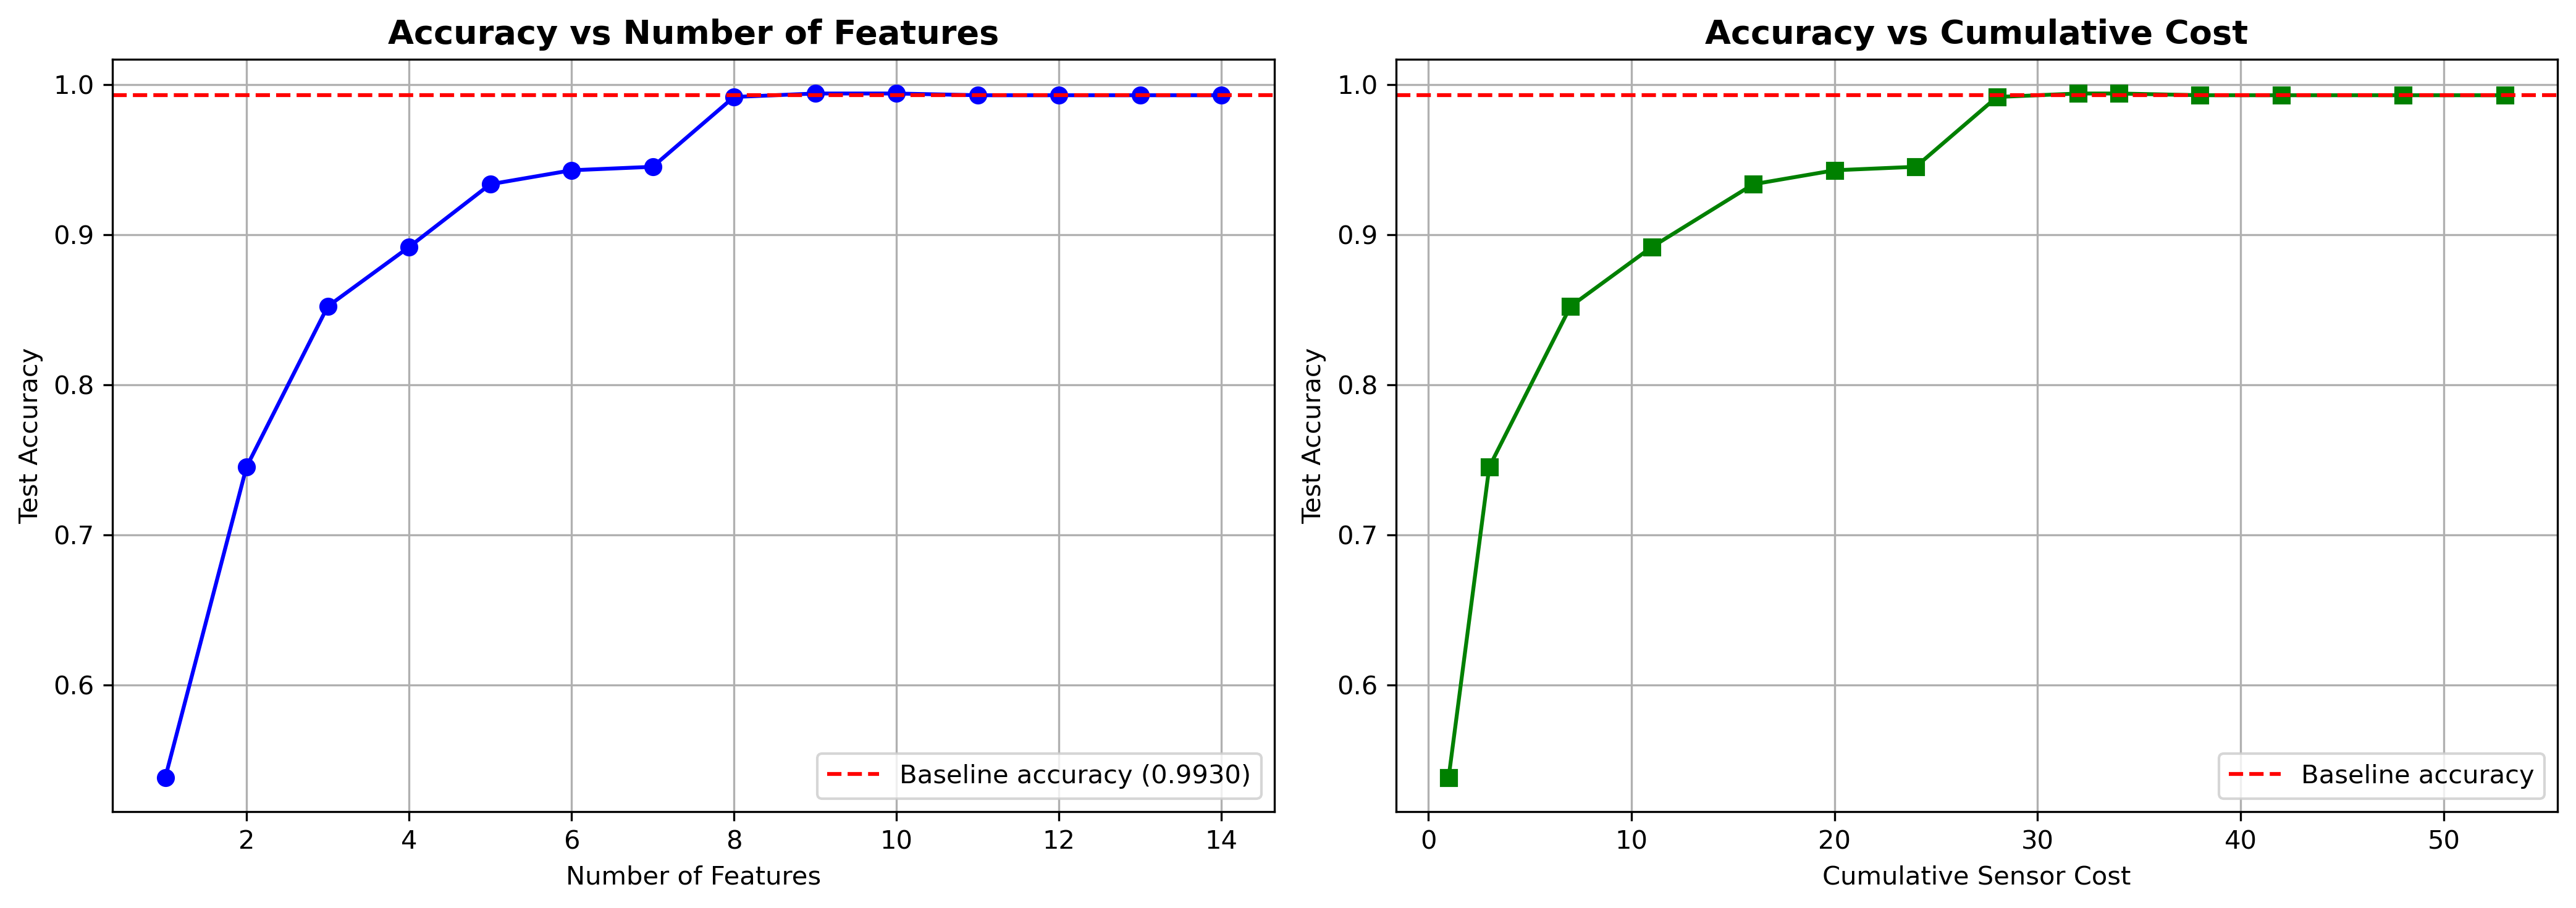

In [28]:
import matplotlib.pyplot as plt

# High-quality figure settings
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

# Accuracy vs Number of Features
ax1.plot(
    n_features_list,
    accuracy_list,
    marker='o',
    linestyle='-',
    color='b'
)

ax1.axhline(
    y=acc_all,
    color='r',
    linestyle='--',
    label=f'Baseline accuracy ({acc_all:.4f})'
)

ax1.set_xlabel('Number of Features')
ax1.set_ylabel('Test Accuracy')
ax1.set_title(
    'Accuracy vs Number of Features',
    fontsize=13,
    fontweight='bold'
)
ax1.grid(True)
ax1.legend()

# Accuracy vs Cumulative Cost
ax2.plot(
    cost_list,
    accuracy_list,
    marker='s',
    linestyle='-',
    color='g'
)

ax2.axhline(
    y=acc_all,
    color='r',
    linestyle='--',
    label='Baseline accuracy'
)

ax2.set_xlabel('Cumulative Sensor Cost')
ax2.set_ylabel('Test Accuracy')
ax2.set_title(
    'Accuracy vs Cumulative Cost',
    fontsize=13,
    fontweight='bold'
)
ax2.grid(True)
ax2.legend()

plt.tight_layout()

# Save as high-quality PNG
plt.savefig(
    "accuracy_vs_features_and_cost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
# # Plot accuracy vs number of features and vs cost
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ax1.plot(n_features_list, accuracy_list, marker='o', linestyle='-', color='b')
# ax1.axhline(y=acc_all, color='r', linestyle='--', label=f'Baseline accuracy ({acc_all:.4f})')
# ax1.set_xlabel('Number of Features')
# ax1.set_ylabel('Test Accuracy')
# ax1.set_title('Accuracy vs Number of Features')
# ax1.grid(True)
# ax1.legend()

# ax2.plot(cost_list, accuracy_list, marker='s', linestyle='-', color='g')
# ax2.axhline(y=acc_all, color='r', linestyle='--', label='Baseline accuracy')
# ax2.set_xlabel('Cumulative Sensor Cost')
# ax2.set_ylabel('Test Accuracy')
# ax2.set_title('Accuracy vs Cumulative Cost')
# ax2.grid(True)
# ax2.legend()

# plt.tight_layout()
# plt.show()